# 02 - Baseline and Linear Models

This notebook implements and compares baseline and linear models for weekly gasoline price forecasting:
- Naive Baseline (last week's price)
- Linear Regression
- Ridge Regression (with cross-validated alpha)
- Lasso Regression (with cross-validated alpha)

We also compare basic vs full feature sets and 1-week vs 4-week horizons.

## 1. Setup

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler

# Add src to path
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))

import data_utils
import evaluate

# Notebook display settings
%matplotlib inline
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.float_format', '{:.6f}'.format)

print('Setup complete.')

Setup complete.


## 2. Load Data

In [2]:
# Prepare data with 1-week horizon and full features
data = data_utils.prepare_data(horizon=1, feature_mode='full')

feature_cols = data['feature_cols']
train_df = data['train']
val_df = data['val']
test_df = data['test']

X_train = train_df[feature_cols].values
y_train = train_df['target'].values
X_val = val_df[feature_cols].values
y_val = val_df['target'].values
X_test = test_df[feature_cols].values
y_test = test_df['target'].values

print(f'Features ({len(feature_cols)}): {feature_cols}')
print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')
print(f'Date range - Train: {train_df["Date"].iloc[0]} to {train_df["Date"].iloc[-1]}')
print(f'Date range - Val:   {val_df["Date"].iloc[0]} to {val_df["Date"].iloc[-1]}')
print(f'Date range - Test:  {test_df["Date"].iloc[0]} to {test_df["Date"].iloc[-1]}')

Features (26): ['A1_lag1', 'A1_lag2', 'A1_lag3', 'A1_lag4', 'A1_lag8', 'A1_lag12', 'A1_rolling_mean_4', 'A1_rolling_std_4', 'A1_rolling_mean_8', 'A1_rolling_std_8', 'A1_rolling_mean_12', 'A1_rolling_std_12', 'A1_diff_1', 'A1_diff_4', 'A1_pct_change_1', 'A1_pct_change_4', 'month', 'quarter', 'year', 'week_of_year', 'month_sin', 'month_cos', 'R1_lag1', 'M1_lag1', 'P1_lag1', 'D1_lag1']
Train: (943, 26), Val: (202, 26), Test: (203, 26)
Date range - Train: 1995-03-27 00:00:00 to 2013-04-15 00:00:00
Date range - Val:   2013-04-22 00:00:00 to 2017-02-27 00:00:00
Date range - Test:  2017-03-06 00:00:00 to 2021-01-18 00:00:00


## 3. Naive Baseline

Predict next week's price as this week's price (i.e., use `A1_lag1` as the prediction).

In [3]:
# Naive baseline: predict next week = this week (A1_lag1)
lag1_col = 'A1_lag1'

y_val_naive = val_df[lag1_col].values
y_test_naive = test_df[lag1_col].values

metrics_val_naive = evaluate.evaluate_model(y_val, y_val_naive)
metrics_test_naive = evaluate.evaluate_model(y_test, y_test_naive)

print('Naive Baseline - Validation:', metrics_val_naive)
print('Naive Baseline - Test:      ', metrics_test_naive)

# Save results
evaluate.save_results(
    model_name='Naive Baseline',
    horizon=1,
    metrics={'val': metrics_val_naive, 'test': metrics_test_naive},
    predictions={'test': y_test_naive},
    dates={'test': test_df['Date'].values},
    feature_mode='full'
)

Naive Baseline - Validation: {'RMSE': np.float64(0.086868), 'MAE': np.float64(0.068084), 'MAPE': np.float64(2.5359)}
Naive Baseline - Test:       {'RMSE': np.float64(0.07662), 'MAE': np.float64(0.057631), 'MAPE': np.float64(2.2794)}
Results saved to /Users/simouchen/Documents/MasterYear/CSCI567/Project/CSCI567_FinalProject/src/../results/naive_baseline_h1_full.json


## 4. Linear Regression

Linear Regression - Validation: {'RMSE': np.float64(0.04461), 'MAE': np.float64(0.035707), 'MAPE': np.float64(1.3252)}
Linear Regression - Test:       {'RMSE': np.float64(0.041244), 'MAE': np.float64(0.030332), 'MAPE': np.float64(1.179)}


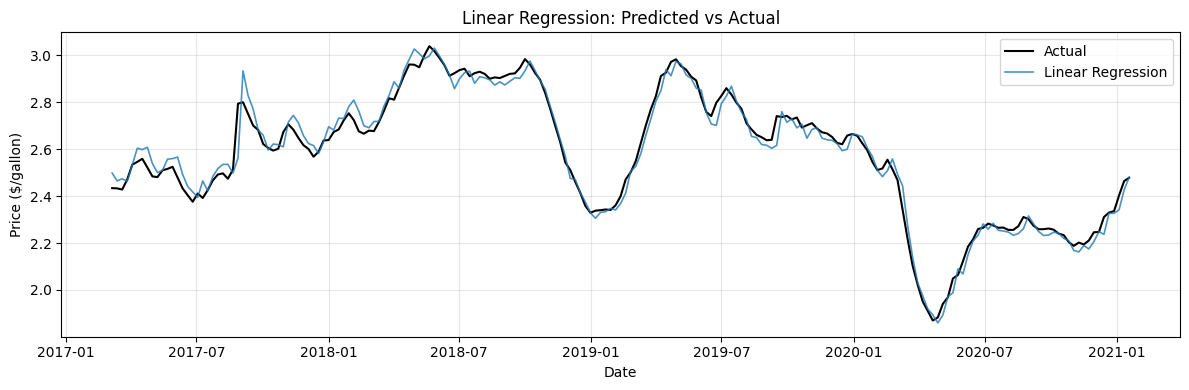

Results saved to /Users/simouchen/Documents/MasterYear/CSCI567/Project/CSCI567_FinalProject/src/../results/linear_regression_h1_full.json


In [4]:
# Standardize features
scaler_lr = StandardScaler()
X_train_scaled = scaler_lr.fit_transform(X_train)
X_val_scaled = scaler_lr.transform(X_val)
X_test_scaled = scaler_lr.transform(X_test)

# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predict
y_val_lr = lr_model.predict(X_val_scaled)
y_test_lr = lr_model.predict(X_test_scaled)

# Evaluate
metrics_val_lr = evaluate.evaluate_model(y_val, y_val_lr)
metrics_test_lr = evaluate.evaluate_model(y_test, y_test_lr)

print('Linear Regression - Validation:', metrics_val_lr)
print('Linear Regression - Test:      ', metrics_test_lr)

# Plot predictions vs actual on test set
evaluate.plot_predictions_vs_actual(
    test_df['Date'].values, y_test, y_test_lr, 'Linear Regression'
)
plt.show()

# Save results
evaluate.save_results(
    model_name='Linear Regression',
    horizon=1,
    metrics={'val': metrics_val_lr, 'test': metrics_test_lr},
    predictions={'test': y_test_lr},
    dates={'test': test_df['Date'].values},
    feature_mode='full'
)

## 5. Ridge Regression

Best alpha: 1.0
Ridge Regression - Validation: {'RMSE': np.float64(0.056693), 'MAE': np.float64(0.048042), 'MAPE': np.float64(1.831)}
Ridge Regression - Test:       {'RMSE': np.float64(0.11188), 'MAE': np.float64(0.104172), 'MAPE': np.float64(4.1335)}


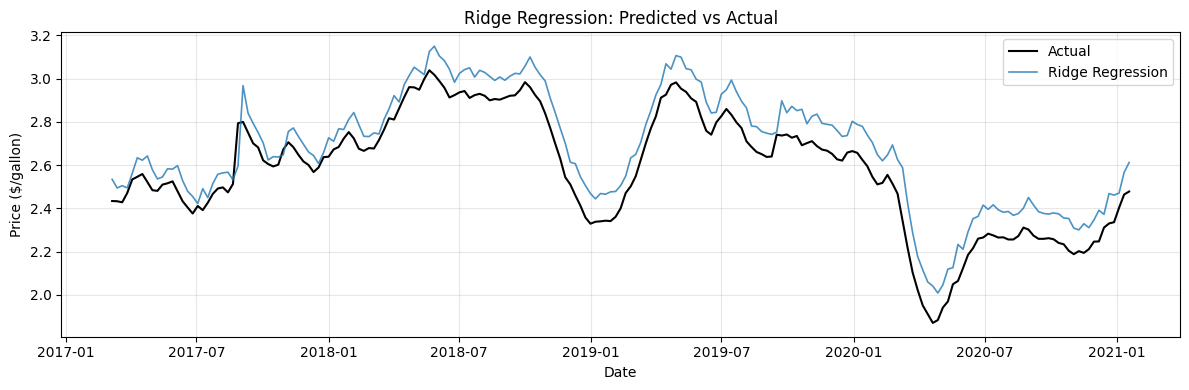

Results saved to /Users/simouchen/Documents/MasterYear/CSCI567/Project/CSCI567_FinalProject/src/../results/ridge_regression_h1_full.json


In [5]:
# Standardize features (reuse same scaler fit on training data)
scaler_ridge = StandardScaler()
X_train_scaled = scaler_ridge.fit_transform(X_train)
X_val_scaled = scaler_ridge.transform(X_val)
X_test_scaled = scaler_ridge.transform(X_test)

# Train Ridge with cross-validation
ridge_model = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100], cv=5)
ridge_model.fit(X_train_scaled, y_train)

print(f'Best alpha: {ridge_model.alpha_}')

# Predict
y_val_ridge = ridge_model.predict(X_val_scaled)
y_test_ridge = ridge_model.predict(X_test_scaled)

# Evaluate
metrics_val_ridge = evaluate.evaluate_model(y_val, y_val_ridge)
metrics_test_ridge = evaluate.evaluate_model(y_test, y_test_ridge)

print('Ridge Regression - Validation:', metrics_val_ridge)
print('Ridge Regression - Test:      ', metrics_test_ridge)

# Plot predictions vs actual on test set
evaluate.plot_predictions_vs_actual(
    test_df['Date'].values, y_test, y_test_ridge, 'Ridge Regression'
)
plt.show()

# Save results
evaluate.save_results(
    model_name='Ridge Regression',
    horizon=1,
    metrics={'val': metrics_val_ridge, 'test': metrics_test_ridge},
    predictions={'test': y_test_ridge},
    dates={'test': test_df['Date'].values},
    feature_mode='full'
)

## 6. Lasso Regression

Best alpha: 0.001
Lasso Regression - Validation: {'RMSE': np.float64(0.044664), 'MAE': np.float64(0.035876), 'MAPE': np.float64(1.3428)}
Lasso Regression - Test:       {'RMSE': np.float64(0.054264), 'MAE': np.float64(0.045186), 'MAPE': np.float64(1.784)}


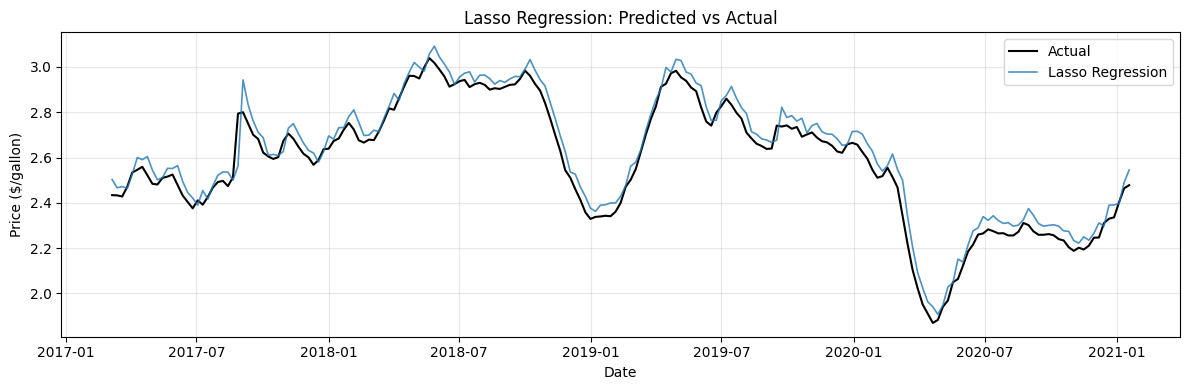

Results saved to /Users/simouchen/Documents/MasterYear/CSCI567/Project/CSCI567_FinalProject/src/../results/lasso_regression_h1_full.json


In [6]:
# Standardize features
scaler_lasso = StandardScaler()
X_train_scaled = scaler_lasso.fit_transform(X_train)
X_val_scaled = scaler_lasso.transform(X_val)
X_test_scaled = scaler_lasso.transform(X_test)

# Train Lasso with cross-validation
lasso_model = LassoCV(alphas=[0.001, 0.01, 0.1, 1, 10], cv=5, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)

print(f'Best alpha: {lasso_model.alpha_}')

# Predict
y_val_lasso = lasso_model.predict(X_val_scaled)
y_test_lasso = lasso_model.predict(X_test_scaled)

# Evaluate
metrics_val_lasso = evaluate.evaluate_model(y_val, y_val_lasso)
metrics_test_lasso = evaluate.evaluate_model(y_test, y_test_lasso)

print('Lasso Regression - Validation:', metrics_val_lasso)
print('Lasso Regression - Test:      ', metrics_test_lasso)

# Plot predictions vs actual on test set
evaluate.plot_predictions_vs_actual(
    test_df['Date'].values, y_test, y_test_lasso, 'Lasso Regression'
)
plt.show()

# Save results
evaluate.save_results(
    model_name='Lasso Regression',
    horizon=1,
    metrics={'val': metrics_val_lasso, 'test': metrics_test_lasso},
    predictions={'test': y_test_lasso},
    dates={'test': test_df['Date'].values},
    feature_mode='full'
)

## 7. Feature Importance (Ridge Coefficients)

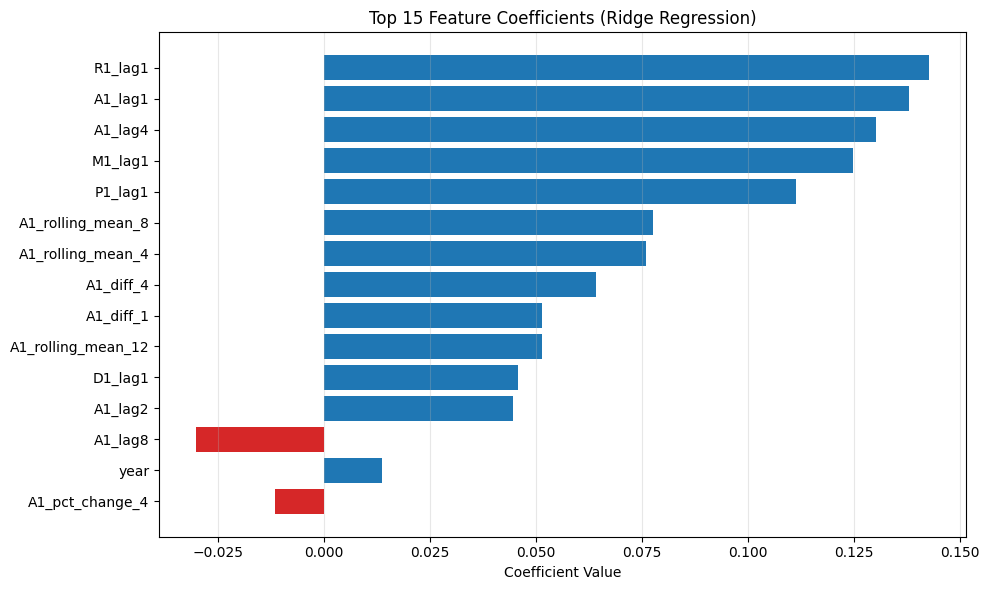


Top 15 features by absolute coefficient:
           feature  coefficient
           R1_lag1     0.142750
           A1_lag1     0.137945
           A1_lag4     0.130298
           M1_lag1     0.124783
           P1_lag1     0.111324
 A1_rolling_mean_8     0.077562
 A1_rolling_mean_4     0.076001
         A1_diff_4     0.064237
         A1_diff_1     0.051480
A1_rolling_mean_12     0.051353
           D1_lag1     0.045921
           A1_lag2     0.044571
           A1_lag8    -0.030092
              year     0.013827
   A1_pct_change_4    -0.011376


In [7]:
# Get feature coefficients from Ridge model
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': ridge_model.coef_
})
coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False)

# Plot top 15 features
top_n = 15
top_features = coef_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['tab:red' if c < 0 else 'tab:blue' for c in top_features['coefficient']]
ax.barh(range(top_n), top_features['coefficient'].values, color=colors)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Coefficient Value')
ax.set_title(f'Top {top_n} Feature Coefficients (Ridge Regression)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print('\nTop 15 features by absolute coefficient:')
print(top_features[['feature', 'coefficient']].to_string(index=False))

## 8. Basic vs Full Features Comparison

Compare Linear Regression with `feature_mode='basic'` (lag-only features) vs `feature_mode='full'` (all engineered features).

In [8]:
# Load data with basic features (lag-only)
data_basic = data_utils.prepare_data(horizon=1, feature_mode='basic')

feature_cols_basic = data_basic['feature_cols']
train_basic = data_basic['train']
val_basic = data_basic['val']
test_basic = data_basic['test']

X_train_basic = train_basic[feature_cols_basic].values
y_train_basic = train_basic['target'].values
X_val_basic = val_basic[feature_cols_basic].values
y_val_basic = val_basic['target'].values
X_test_basic = test_basic[feature_cols_basic].values
y_test_basic = test_basic['target'].values

print(f'Basic features ({len(feature_cols_basic)}): {feature_cols_basic}')
print(f'Full features ({len(feature_cols)}): {len(feature_cols)} total')

Basic features (6): ['A1_lag1', 'A1_lag2', 'A1_lag3', 'A1_lag4', 'A1_lag8', 'A1_lag12']
Full features (26): 26 total


In [9]:
# Train Linear Regression with basic features
scaler_basic = StandardScaler()
X_train_basic_scaled = scaler_basic.fit_transform(X_train_basic)
X_val_basic_scaled = scaler_basic.transform(X_val_basic)
X_test_basic_scaled = scaler_basic.transform(X_test_basic)

lr_basic = LinearRegression()
lr_basic.fit(X_train_basic_scaled, y_train_basic)

y_val_lr_basic = lr_basic.predict(X_val_basic_scaled)
y_test_lr_basic = lr_basic.predict(X_test_basic_scaled)

metrics_val_lr_basic = evaluate.evaluate_model(y_val_basic, y_val_lr_basic)
metrics_test_lr_basic = evaluate.evaluate_model(y_test_basic, y_test_lr_basic)

print('Linear Regression (basic) - Validation:', metrics_val_lr_basic)
print('Linear Regression (basic) - Test:      ', metrics_test_lr_basic)
print()
print('Linear Regression (full)  - Validation:', metrics_val_lr)
print('Linear Regression (full)  - Test:      ', metrics_test_lr)

# Save basic results
evaluate.save_results(
    model_name='Linear Regression',
    horizon=1,
    metrics={'val': metrics_val_lr_basic, 'test': metrics_test_lr_basic},
    predictions={'test': y_test_lr_basic},
    dates={'test': test_basic['Date'].values},
    feature_mode='basic'
)

Linear Regression (basic) - Validation: {'RMSE': np.float64(0.0741), 'MAE': np.float64(0.057643), 'MAPE': np.float64(2.1046)}
Linear Regression (basic) - Test:       {'RMSE': np.float64(0.066627), 'MAE': np.float64(0.048103), 'MAPE': np.float64(1.8643)}

Linear Regression (full)  - Validation: {'RMSE': np.float64(0.04461), 'MAE': np.float64(0.035707), 'MAPE': np.float64(1.3252)}
Linear Regression (full)  - Test:       {'RMSE': np.float64(0.041244), 'MAE': np.float64(0.030332), 'MAPE': np.float64(1.179)}
Results saved to /Users/simouchen/Documents/MasterYear/CSCI567/Project/CSCI567_FinalProject/src/../results/linear_regression_h1_basic.json


## 9. 4-Week Horizon (Ridge Regression)

Repeat the best model (Ridge) with `horizon=4` and compare to the 1-week horizon results.

In [10]:
# Prepare data with 4-week horizon
data_h4 = data_utils.prepare_data(horizon=4, feature_mode='full')

feature_cols_h4 = data_h4['feature_cols']
train_h4 = data_h4['train']
val_h4 = data_h4['val']
test_h4 = data_h4['test']

X_train_h4 = train_h4[feature_cols_h4].values
y_train_h4 = train_h4['target'].values
X_val_h4 = val_h4[feature_cols_h4].values
y_val_h4 = val_h4['target'].values
X_test_h4 = test_h4[feature_cols_h4].values
y_test_h4 = test_h4['target'].values

print(f'4-week horizon - Train: {X_train_h4.shape}, Val: {X_val_h4.shape}, Test: {X_test_h4.shape}')

4-week horizon - Train: (941, 26), Val: (202, 26), Test: (202, 26)


Best alpha (4-week): 100.0

Ridge (1-week) - Test: {'RMSE': np.float64(0.11188), 'MAE': np.float64(0.104172), 'MAPE': np.float64(4.1335)}
Ridge (4-week) - Test: {'RMSE': np.float64(0.257989), 'MAE': np.float64(0.231568), 'MAPE': np.float64(9.3024)}


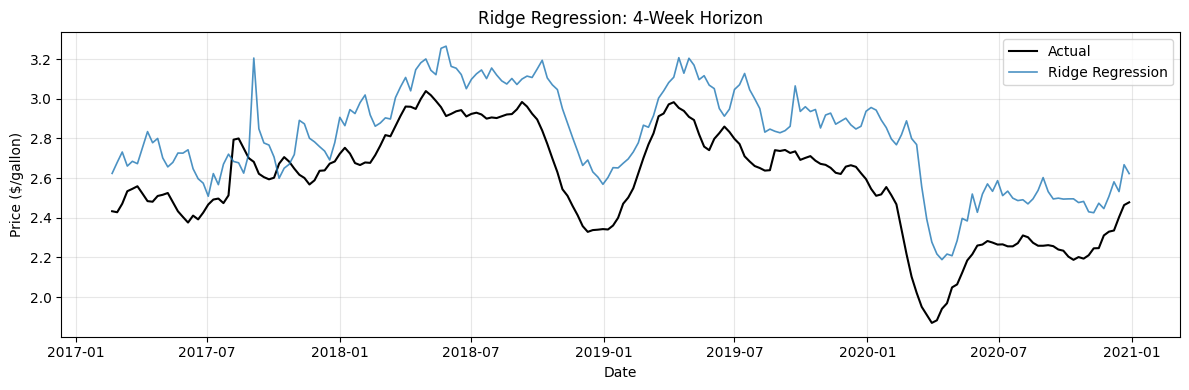

Results saved to /Users/simouchen/Documents/MasterYear/CSCI567/Project/CSCI567_FinalProject/src/../results/ridge_regression_h4_full.json


In [11]:
# Train Ridge with 4-week horizon
scaler_h4 = StandardScaler()
X_train_h4_scaled = scaler_h4.fit_transform(X_train_h4)
X_val_h4_scaled = scaler_h4.transform(X_val_h4)
X_test_h4_scaled = scaler_h4.transform(X_test_h4)

ridge_h4 = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100], cv=5)
ridge_h4.fit(X_train_h4_scaled, y_train_h4)

print(f'Best alpha (4-week): {ridge_h4.alpha_}')

y_val_ridge_h4 = ridge_h4.predict(X_val_h4_scaled)
y_test_ridge_h4 = ridge_h4.predict(X_test_h4_scaled)

metrics_val_ridge_h4 = evaluate.evaluate_model(y_val_h4, y_val_ridge_h4)
metrics_test_ridge_h4 = evaluate.evaluate_model(y_test_h4, y_test_ridge_h4)

print('\nRidge (1-week) - Test:', metrics_test_ridge)
print('Ridge (4-week) - Test:', metrics_test_ridge_h4)

# Plot
evaluate.plot_predictions_vs_actual(
    test_h4['Date'].values, y_test_h4, y_test_ridge_h4,
    'Ridge Regression', title='Ridge Regression: 4-Week Horizon'
)
plt.show()

# Save results
evaluate.save_results(
    model_name='Ridge Regression',
    horizon=4,
    metrics={'val': metrics_val_ridge_h4, 'test': metrics_test_ridge_h4},
    predictions={'test': y_test_ridge_h4},
    dates={'test': test_h4['Date'].values},
    feature_mode='full'
)

## 10. Summary Table

Compare all models evaluated in this notebook.


=== Model Comparison (Test Set) ===


,Model,Horizon,Features,RMSE,MAE,MAPE (%)
0,Linear Regression,1,full,0.041244,0.030332,1.179000
1,Lasso Regression,1,full,0.054264,0.045186,1.784000
2,Linear Regression,1,basic,0.066627,0.048103,1.864300
3,Naive Baseline,1,full,0.076620,0.057631,2.279400
4,Ridge Regression,1,full,0.111880,0.104172,4.133500
5,Ridge Regression,4,full,0.257989,0.231568,9.302400


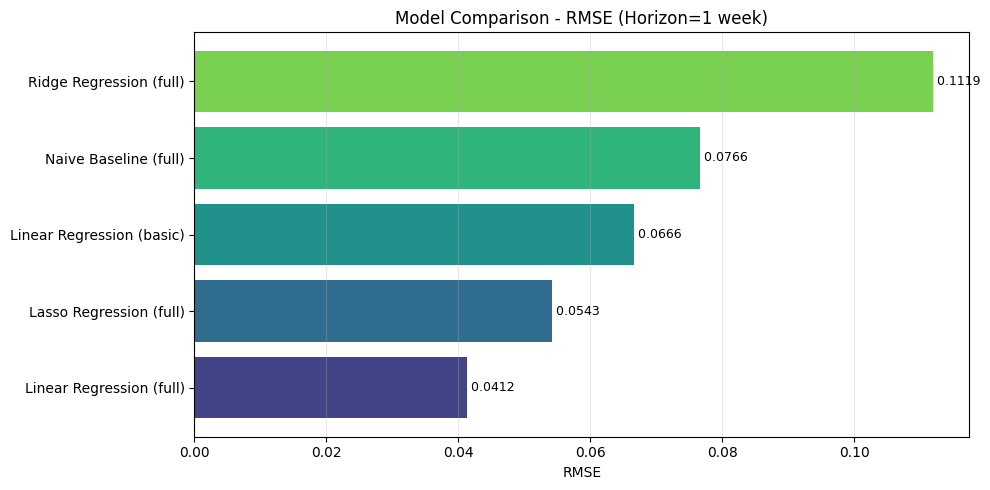

In [12]:
# Build summary table from all results saved so far
summary_results = [
    {'model_name': 'Naive Baseline', 'horizon': 1, 'feature_mode': 'full',
     'metrics': {'test': metrics_test_naive}},
    {'model_name': 'Linear Regression', 'horizon': 1, 'feature_mode': 'full',
     'metrics': {'test': metrics_test_lr}},
    {'model_name': 'Linear Regression', 'horizon': 1, 'feature_mode': 'basic',
     'metrics': {'test': metrics_test_lr_basic}},
    {'model_name': 'Ridge Regression', 'horizon': 1, 'feature_mode': 'full',
     'metrics': {'test': metrics_test_ridge}},
    {'model_name': 'Lasso Regression', 'horizon': 1, 'feature_mode': 'full',
     'metrics': {'test': metrics_test_lasso}},
    {'model_name': 'Ridge Regression', 'horizon': 4, 'feature_mode': 'full',
     'metrics': {'test': metrics_test_ridge_h4}},
]

comparison_df = evaluate.build_comparison_table(summary_results)
print('\n=== Model Comparison (Test Set) ===')
display(comparison_df)

# Bar chart for 1-week horizon
evaluate.plot_comparison_bar(comparison_df, metric='RMSE', horizon=1)
plt.show()